## **First Look at Data**

In [1]:
import xarray as xr
import xroms
import xcmocean
import matplotlib.pyplot as plt
import os
import numpy as np
import pandas as pd

**Function to load data into a dataframe**

In [2]:
def open_pactcs30(year):
    path = "../../../GROUP/pactcs30/pactcs30_" + str(year) + "_avg.zarr"
    # dates on the original ROMS output have the wrong time
    ds = xr.open_zarr(path, decode_times=False)
    # we have to set the units and calendar from 0000-01-01 00:00:00 and 365noleap
    ds['time'].attrs['units'] = "seconds since 1979-01-01 00:00:00"
    ds['time'].attrs['calendar'] = "gregorian"
    ds = xr.decode_cf(ds)  # now, interpret the calendar
    # read in the data with ROMS package - allows for easy plotting
    ds, _ = xroms.roms_dataset(ds, include_3D_metrics=False)
    return ds

def open_pactcs30_all():
    data = [open_pactcs30(year) for year in range(2000, 2020)]
    return xr.concat(data, dim="time")

**Load data**

In [3]:
pactcs30_data = []

for i in range(2000, 2020):
    pactcs30_data.append(open_pactcs30(i))

#pactcs30_all = open_pactcs30_all()

**Plot desired variable**

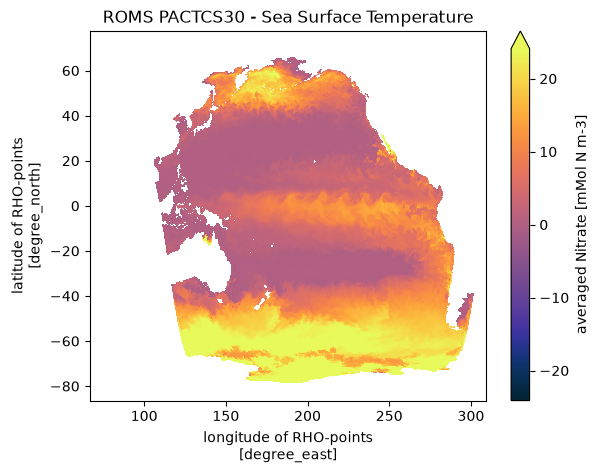

2000-12-04T12:05:00.000000000


In [41]:
pactcs30_data[0].NO3.isel(time=338).cf.plot(
    x="longitude",
    y="latitude",
    robust=True,
    cmap="cmo.thermal",
)
plt.title("ROMS PACTCS30 - Sea Surface Temperature")
plt.show()
print(pactcs30_data[0].time.isel(time=338).values)

## **Exploratory Data Analysis**

### **1. Contents of the data**

**Metadata of the data**

In [11]:
pactcs30_data[0]

<xarray.Dataset> Size: 5GB
Dimensions:   (eta_rho: 518, xi_rho: 604, time: 366, s_rho: 1, xi_u: 603,
               eta_v: 517)
Coordinates:
    lat_rho   (eta_rho, xi_rho) float32 1MB dask.array<chunksize=(518, 604), meta=np.ndarray>
    lon_rho   (eta_rho, xi_rho) float32 1MB dask.array<chunksize=(518, 604), meta=np.ndarray>
  * time      (time) datetime64[ns] 3kB 2000-01-01T12:05:00 ... 2000-12-31T12...
Dimensions without coordinates: eta_rho, xi_rho, s_rho, xi_u, eta_v
Data variables: (12/16)
    angle     (eta_rho, xi_rho) float32 1MB dask.array<chunksize=(518, 604), meta=np.ndarray>
    DIC       (time, s_rho, eta_rho, xi_rho) float32 458MB dask.array<chunksize=(1, 1, 518, 604), meta=np.ndarray>
    f         (eta_rho, xi_rho) float32 1MB dask.array<chunksize=(518, 604), meta=np.ndarray>
    h         (eta_rho, xi_rho) float32 1MB dask.array<chunksize=(518, 604), meta=np.ndarray>
    mask_rho  (eta_rho, xi_rho) float32 1MB dask.array<chunksize=(518, 604), meta=np.ndarray>
    NO3       (time, s_rho, eta_rho, xi_rho) float32 458MB dask.array<chunksize=(1, 1, 518, 604), meta=np.ndarray>
    ...        ...
    temp      (time, s_rho, eta_rho, xi_rho) float32 458MB dask.array<chunksize=(1, 1, 518, 604), meta=np.ndarray>
    TOT_CHL   (time, s_rho, eta_rho, xi_rho) float32 458MB dask.array<chunksize=(1, 1, 518, 604), meta=np.ndarray>
    u         (time, s_rho, eta_rho, xi_u) float32 457MB dask.array<chunksize=(1, 1, 518, 603), meta=np.ndarray>
    v         (time, s_rho, eta_v, xi_rho) float32 457MB dask.array<chunksize=(1, 1, 517, 604), meta=np.ndarray>
    w         (time, s_rho, eta_rho, xi_rho) float32 458MB dask.array<chunksize=(1, 1, 518, 604), meta=np.ndarray>
    zeta      (time, eta_rho, xi_rho) float32 458MB dask.array<chunksize=(1, 518, 604), meta=np.ndarray>
Attributes: (12/33)
    type:           ROMS averages file
    title:          PACIFIC stretched 6.1km to 65km
    grid_file:      /cluster/home/fdesmet/fdscratch/pactcs30/8x48/grd_merged/...
    init_file:      /nfs/meso/work/fdesmet/roms/output/pactcs30/hc006_daily_p...
    ntimes:         52704
    ndtfast:        45
    ...             ...
    rdrg2_units:    nondimensional
    Zob:            0.004000000189989805
    Zob_units:      meter
    SRCS:           KRNSRC main.F step2D_FB.F read_inp.F read_sta_pos.F set_w...
    CPPS:           <cppdefs_UP.h> SOLVE3D UV_ADV UV_COR NONLIN_EOS SPLIT_EOS...
    nc_format:      netCDF-4, zlib-compressed

| Category | Variable | Description | Units / Notes | Datatype | Dimensions | Question |
| :--- | :--- | :--- | :--- | :--- | :--- | :--- |
| **Physical** 
| | `u` | Surface u-momentum component (eastward-like) | $\text{m}\,\text{s}^{-1}$ | float32 | (time, s_rho, eta_rho, xi_u) | |
| | `v` | Surface v-momentum component (northward-like) | $\text{m}\,\text{s}^{-1}$ | float32 | (time, s_rho, eta_v, xi_rho) | |
| | `w` | Surface vertical momentum component | $\text{m}\,\text{s}^{-1}$ | float32 | (time, s_rho, eta_rho, xi_rho) | |
| | `temp` | Potential temperature | $^\circ\text{C}$ | float32 | (time, s_rho, eta_rho, xi_rho) | |
| | `salt` | Salinity | $\text{PSU (Practical Salinity Unit)}$ | float32 | (time, s_rho, eta_rho, xi_rho) | |
| | `zeta` | Sea surface height (free surface elevation) | $\text{m}$ | float32 | (time, eta_rho, xi_rho) | |
| **Biogeochemical** 
| | `NO3` | Nitrate concentration | $\text{mmol}\,\text{m}^{-3}$ | float32 | (time, s_rho, eta_rho, xi_rho) | |
| | `DIC` | Dissolved Inorganic Carbon | $\text{mmol}\,\text{m}^{-3}$ | float32 | (time, s_rho, eta_rho, xi_rho) | |
| | `PCO2OC` | Partial pressure of $\text{CO}_2$ in seawater | $\mu\text{atm (atmospheric pressure)}$ | float32 | (time, eta_rho, xi_rho) | why is there no depth component? |
| | `TOT_CHL` | Total chlorophyll concentration | $\text{mg}\,\text{m}^{-3}$ | float32 | (time, s_rho, eta_rho, xi_rho) | |
| **Grid & Metrics**
| | `eta_rho`, `xi_rho` | Y\X component of grid | | int64 | | |
| | `eta_v`, `xi_u` | Y\X component of velocity grid| | int64 | | |
| | `lat_rho`, `lon_rho` | Latitude\longitude of $\rho$-points | $\text{degrees}$ | float32 | (eta_rho, xi_rho) | | 
| | `time` | Time of simulation step | | datetime64[ns] | | |
| | `h` | Bathymetry (ocean depth) | $\text{m}$ | float32 | (eta_rho, xi_rho) | |
| *(Required by `xroms`)* | `f` | Coriolis parameter | $\text{s}^{-1}$ | float32 | (eta_rho, xi_rho) | |
| | `pm`, `pn` | Curvilinear grid scale factors | $\Delta x = 1/pm$, $\Delta y = 1/pn$ | float32 | (eta_rho, xi_rho) | |
| | `angle` | Curvilinear grid rotation angle (angle between $\xi$-axis and east)| $\text{radians}$ | float32 | (eta_rho, xi_rho) | |
| | `mask_rho` | Land-sea mask on $\rho$-points | 0 = land, 1 = water | float32 | (eta_rho, xi_rho) | |
| | `dx`, `dy,` | Inverse curvilinear scaling factor for $\xi$ and $\eta$ | $\text{m}$ | float32 |  (eta_rho, xi_rho) | |
| | `dx_u`, `dy_u,` | Inverse curvilinear scaling factor for $\xi$ and $\eta$ on the u grid | $\text{m}$ | float32 | (eta_rho, xi_u) | |
| | `dx_v`, `dy_v,` | Inverse curvilinear scaling factor for $\xi$ and $\eta$ on the v grid | $\text{m}$ | float32 | (eta_v, xi_rho) | |
| | `dx_psi`, `dy_psi,` | Inverse curvilinear scaling factor for $\xi$ and $\eta$ on the PSI grid | $\text{m}$ | float32 | (eta_v, xi_u) | why is this measured on the u, v grid? |
| | `dA` | Area of $\xi$ and $\eta$ at $\rho$ points | $m^2$ | float32 |  (eta_rho, xi_rho) | |
| | `rho0` | Refference seawater density | $kg/m^3$ | int64 | | |

**Relevant calculations**

In [31]:
print(f"Southernmost point: {np.min(pactcs30_data[0].lat_rho.values)}")
print(f"Northernmost point: {np.max(pactcs30_data[0].lat_rho.values)}")
print(f"Westernmost point {np.min(pactcs30_data[0].lon_rho.values)}")
print(f"Easternmost point {np.max(pactcs30_data[0].lon_rho.values)}")

Southernmost point: -86.16846466064453
Northernmost point: 77.43124389648438
Westernmost point 66.90254211425781
Easternmost point 309.2793273925781


In [ ]:
p

* **What are the spatial coordinates:** The data is forms a curvilinear grid which ranges from roughly -86, 66 to 77, 309. Interesting to note, for Latitude, negative values are used, for longitued the values wrap arround.
* **What is the temporal resultion:** The data is a daily average.
* **What is the depth level:** Currently there is only one depth level located 20 meters below sea level. More depth levels could be added later.
*  **What period and geographic regions are involved:** The data is a 20 year hindcast simulation from 2000 to 2019 and shows the pacific ocean.

### **2. How is the data structured**

**Relevant calculations**

In [8]:
total = 0
outliers = []
quantities = []
size = 0

for i, data in enumerate(pactcs30_data):
    time = data.sizes["time"]
    size += data.nbytes / 1024**3
    total += time
    
    if i % 4 == 0:
        if time < 366:
            outliers.append(2000+i)

    else:
        if time < 365:
            outliers.append(2000+i)

    # uncomment if you want to generate quantities.csv, takes a while
    """ for key in data.data_vars:
        nan_tot = data[key].isnull().sum().compute().values
        val_tot = data[key].notnull().sum().compute().values
        nan_frac = nan_tot/data[key].size

        quantities.append({
            "year": i,
            "variable": key,
            "total nan": nan_tot,
            "total values": val_tot,
            "percentage of nan": nan_frac
        })
        
df = pd.DataFrame(quantities)
df.to_csv("quantities.csv", index=False)"""

print(f"Total datapoints: {total}")
print(f"Years with missing datapoints: {outliers}")
print(f"Total size of all files: {size}GiB")
print(f"Missing data analysis can be found in quantities.csv")

Total datapoints: 7305
Years with missing datapoints: []
Total size of all files: 85.50843046978116GiB
Missing data analysis can be found in quantities.csv


* **How many grid points are there:** The ROMS simulation uses an Arakawa C-grid, meaning that quantity measurements are taken at the center of a grid point, called $\rho$-points, while velocity measurements are staggered to the side. Furthermore Velocity is measured eastward, denoted u, and northward, denoted v. This means that the dimension of the $\rho$-points is 604 x 518 but only 603 x 617 for the v and u points. Note: The velocity relative to the surface is measured at the $\rho$ points.
* **How many time steps are there:** The data is divided into yearly sections where each day there is one simulation step, which sums up to 7305 total simulation steps.
* **Are there any gaps in Space or Time:** There is no day missing.
* **How big and complete is the data:** The data has no missing values, the entire size is about 85 GiB large. Data for the NO3 and total chlorophyll levels behave weirdly by leveling out instantaneously every year, which is probably not correct.

### **3. Statistics of the Data**

**Relevant calculations**

In [ ]:
relev_quant = ["u", "v", "w", "temp", "salt", "zeta", "NO3", "DIC", "PCO2OC", "TOT_CHL"]
statistics = []

# Results can be found in statistics.csv, running this script takes ~30 min.
for i, data in enumerate(pactcs30_data):
    for quant in relev_quant:
        stat = dict()

        stat["year"] = 2000 + i
        stat["variable"] = quant
        stat["mean"] = np.nanmean(data[quant])
        stat["median"] = np.nanmedian(data[quant])
        stat["min"] = np.nanmin(data[quant])
        stat["max"] = np.nanmax(data[quant])
        stat["standard deviation"] = np.nanstd(data[quant])
        stat["Q1"] = np.nanpercentile(data[quant], 25)
        stat["Q3"] = np.nanpercentile(data[quant], 75)
        stat["Interquartile"] = stat["Q3"] - stat["Q1"]
    
        statistics.append(stat)
    print(f"Finished year: {2000+i}")

df = pd.DataFrame(statistics)
df.to_csv("statistics.csv", index=False)

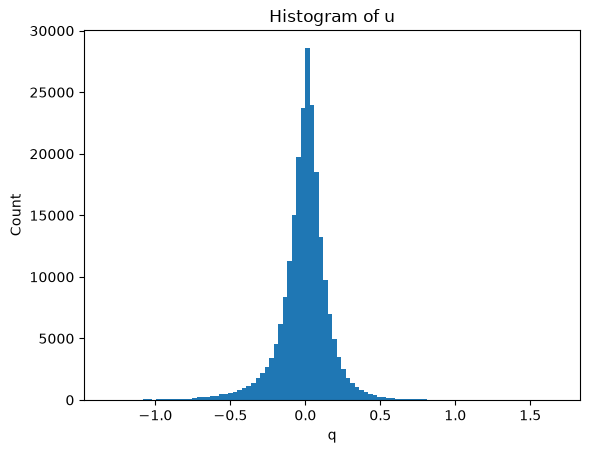

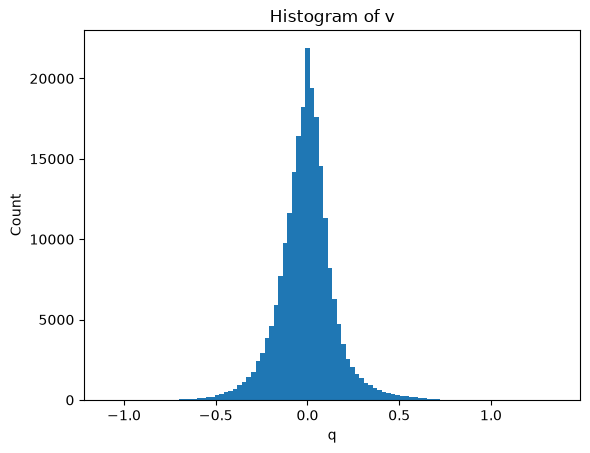

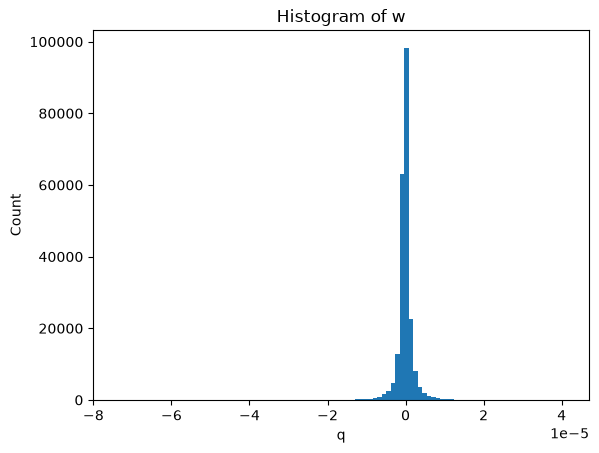

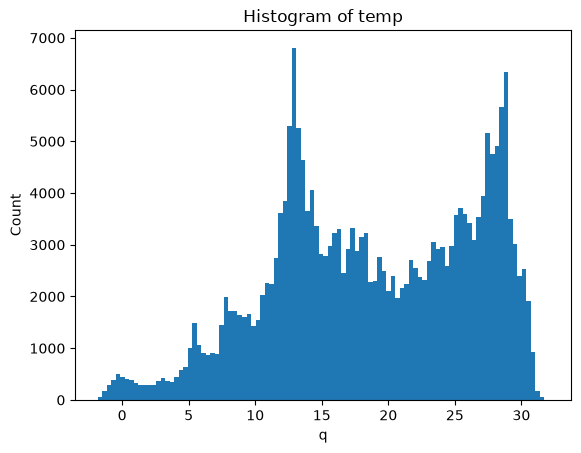

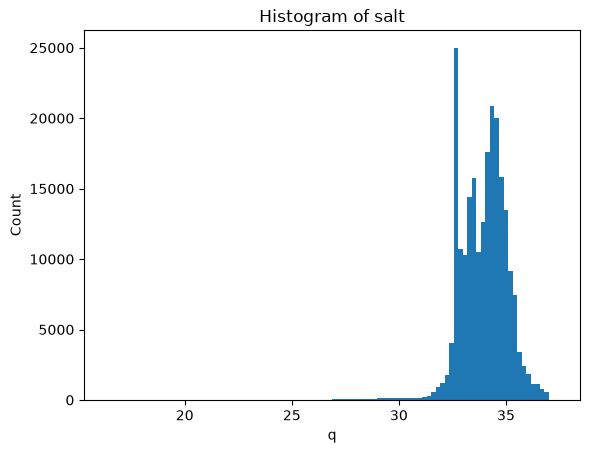

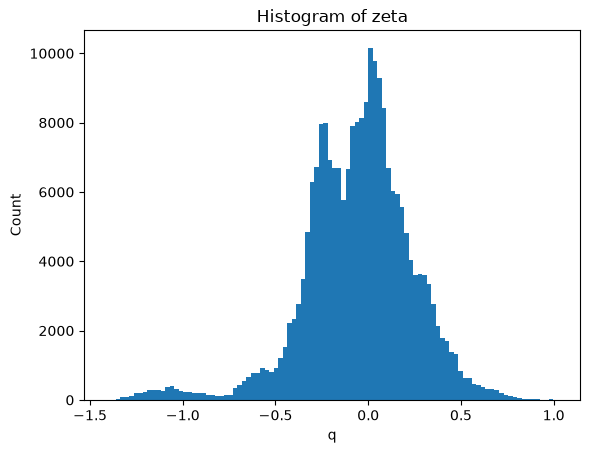

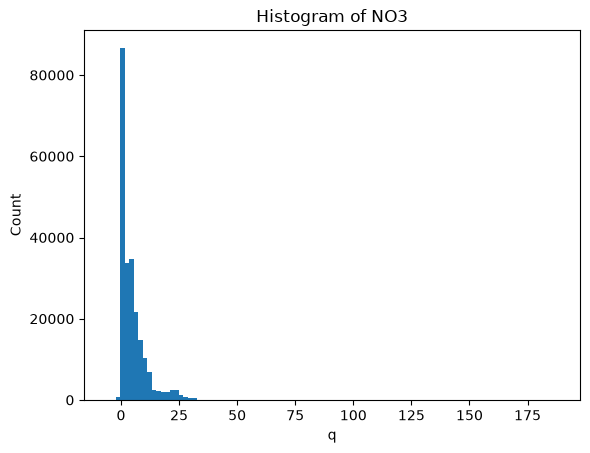

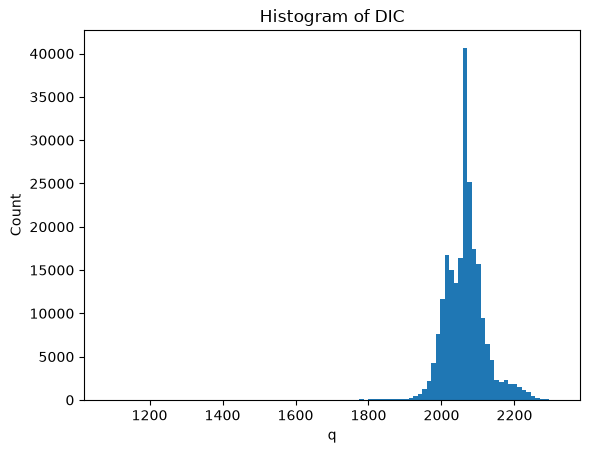

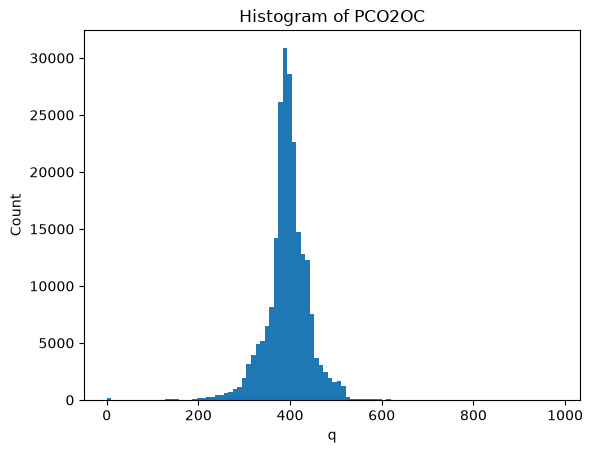

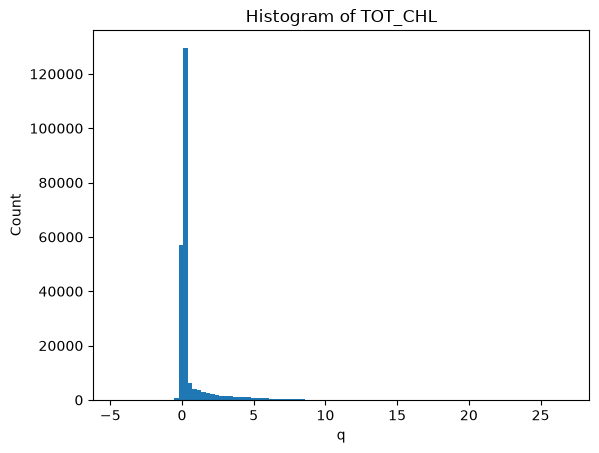

In [46]:
for q in ["u", "v", "w", "temp", "salt", "zeta", "NO3", "DIC", "PCO2OC", "TOT_CHL"]:
    values = pactcs30_data[19][q].isel(time=150).values.ravel()
    
    plt.hist(values, bins=100)
    plt.xlabel(f"q")
    plt.ylabel("Count")
    plt.title(f"Histogram of {q}")
    plt.show()

**Results**

* **Current in u direction:** u-Momentum is mostly 0 with some few regions having higher currents.
    * mean & median: $\sim 0$
    * min & max: $\sim [-2, 2]$
    * $\sigma$: $\sim 0.2$
    * Q1 - Q3: $\sim (-0.3, 0.1)$
* **Current in v direction:** Same as currents in u direction. Median is consistently 0.0 which shouldnt be the case, probably an error in the data.
    * mean & median: $\sim 0$
    * min & max: $\sim [-2, 2]$
    * $\sigma$: $\sim 0.2$
    * Q1 - Q3: $\sim (-0.1, 0.1)$
* **Current in w direction:** There is basically no up or downward momentum close to the surface.
    * mean & median: $\sim 0$
    * min & max: $\sim 0$
    * $\sigma$: $\sim 0$
    * Q1 - Q3: $\sim (0, 0)$
* **Temperature:** Temperature has a greater variety ranging from 0 to 30 degrees with an average of 18 degrees. Mean and median as well as Q1 and Q3 raise slightly over the 20 year span.
    * mean & median: $\sim 19$
    * min & max: $\sim [-2, 32]$
    * $\sigma$: $\sim 7.5$
    * Q1 - Q3: $\sim (13, 25)$
* **Salinity:** Salt concentration is roughly 34 PSU on average with most values close by. There are some extreme outliers with 12 and 37 PSU respectively. 
    * mean & median: $\sim 34$
    * min & max: $\sim [12, 37]$
    * $\sigma$: $\sim 1$
    * Q1 - Q3: $\sim (33, 35)$
* **Sea level:** Sea level is roughly around 0m above sea level :) with little deviation. The lowest areas are twice as low as the highes.
    * mean & median: $\sim 0$
    * min & max: $\sim [-2, 1]$
    * $\sigma$: $\sim 0.5$
    * Q1 - Q3: $\sim (-0.2, 0.1)$
* **Disolved inorganic carbon:** The total DIC rose from 2050 to 2060 $\text{mmol}/\text{m}^{-3}$ with the min and max values varying strongly. The max values hovered around 2350 but the min values shot as high as 1000 $\text{mmol}/\text{m}^{-3}$. The Q1 and Q3 values rose up until $\sim (2025, 2090)$.
    * mean & median: $\sim 2050$ 
    * min & max: $\sim [825, 2350]$ 
    * $\sigma$: $\sim 60$
    * Q1 - Q3: $\sim (2020, 2080)$ 
* **Partial CO2 pressure:** The partial co2 pressure rose consistenly from 3060 to 390 $\mu\text{atm}$ with a bit of variance. The max value varying strongly from 1000 to 1400. The min was always 0.0 which is probably an error. Q1 and Q3 also rose consistently from (340, 380) to (375, 420)
    * mean & median: $\sim 360$ 
    * min & max: $\sim [0, 1250]$ 
    * $\sigma$: $\sim 44$
    * Q1 - Q3: $\sim (340, 380)$ raise 375, 420

### **4. Spatiotemporal Distribution of the Data**

**Plot data**

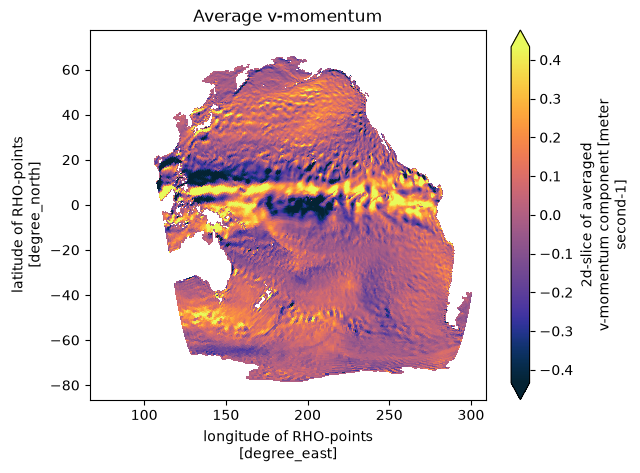

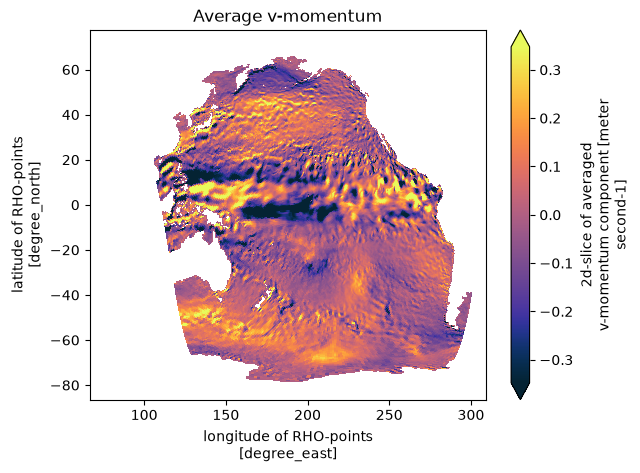

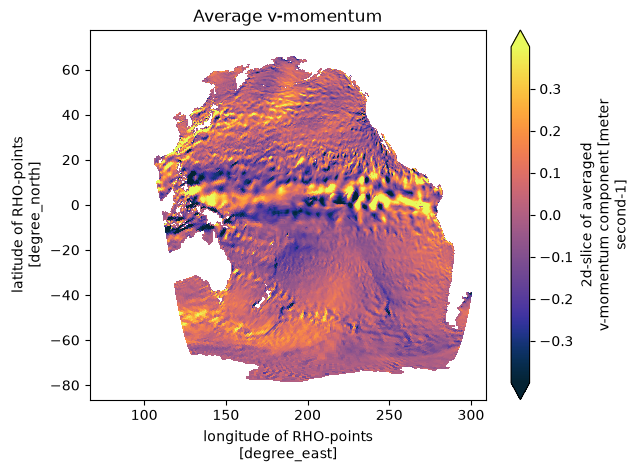

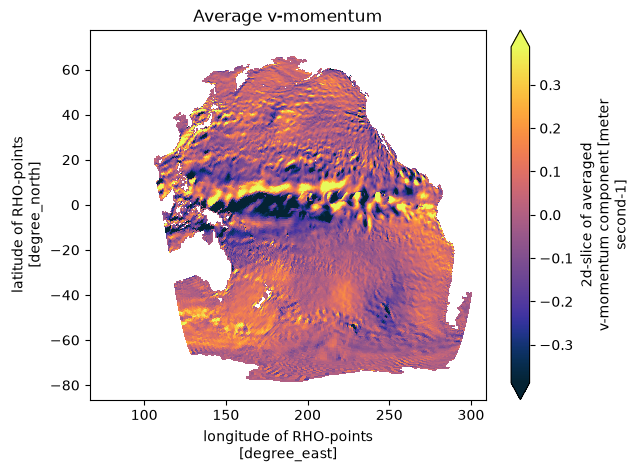

In [18]:
# relev_quant = ["u", "v", "w", "temp", "salt", "zeta", "NO3", "DIC", "PCO2OC", "TOT_CHL"]

def plot_quant_season(quant, year):
    year -= 2000

    # Map u and v onto the rho points by interpolating
    if quant in ["u", "v"]:
        vel_data = pactcs30_data[year]

        u_rho = 0.5 * (vel_data.u.isel(xi_u=slice(0,-1)) + vel_data.u.isel(xi_u=slice(1, None)))
        u_rho["xi_u"] = u_rho["xi_u"] + 1
        u_rho = u_rho.rename({"xi_u" : "xi_rho"})
        
        v_rho = 0.5 * (vel_data.v.isel(eta_v=slice(0,-1)) + vel_data.v.isel(eta_v=slice(1, None)))
        v_rho["eta_v"] = v_rho["eta_v"] + 1
        v_rho = v_rho.rename({"eta_v" : "eta_rho"})
        
        vel_set = xr.Dataset({
            "u" : u_rho,
            "v" : v_rho,
        })
        
        vel_set = vel_set.assign_coords(lat_rho=vel_data["lat_rho"])
        vel_set = vel_set.assign_coords(lon_rho=vel_data["lon_rho"])
        
        for i in [0, 91, 182, 273]:
            vel_set[quant].isel(time=i).cf.plot(
                x="longitude",
                y="latitude",
                robust=True,
                cmap="cmo.thermal",
            )
            
            plt.title(f"Average {quant}-momentum")
            plt.show()
    else:
        for i in [0, 91, 182, 364]:
            pactcs30_data[year][quant].isel(time=i).cf.plot(
                x="longitude",
                y="latitude",
                robust=True,
                cmap="cmo.thermal",
            )
            
            plt.title(f"Average levels of {quant}")
            plt.show()

plot_quant_season("v", 2019)

**How does each important variable change with position and time**

To analyze how the variables are distributed in space and time i will be looking at 4 equidistantly spaced times throughout the year 2010 and compare them to eachother.

* **Current in u direction:** Generally there is a eastward current on the equator with westward currents above and below. In spring the eastward current seizes to return in summer again. Between Australia and the southern part of south america there is a steady westward current that is stronger in winter and slows down throughout the year. Of the coast of Japan and the US we see the same westward current which also decreases with passing time. 
* **Current in v direction:** The v-momentum behaves identically to its u counterpart. There is a northward current arround the equator with southward currents ontop and below. Here aswell the northward current weakens over spring. In both the north and southpacific there are strong northward currents which weaken as time passes.
* **Current in w direction:** Most upward or downward movement of currents is arround the equator with little change over the seasons. There is also some activity in the north pacific, arround the south pole and close to the islands above Australia and Japan.
* **Temperature:** Temperature correlates with latitude as expected with some colder areas on the equator that are more prevalent during fall and winter.
* **Salinity:** There are two high salinity regions below and above the equator with lower salinity on the equator itself. Salinity drops of in the north and south pacific with salinity levels around the antarctic being lowest in winter and rising throughout the year.
* **Sea level:** The sea levels stay steady year round with high elevation in the west pacific, below and above the equator. Sea levels drop in the north and south pacific with the lowest levels being above the antarctic.
* **Disolved inorganic carbon:** Disolved inorganic carbon levels are highest around the antarctic and the north pacific, with levels in the north pacific dropping arround summer. The coast of south america also shows higher levels which fluctuate in size over the year. Around the equator there is a lower level area the entire year.
* **Partial CO2 pressure:** The partial CO2 pressure is highest arround the equator and lowest arround the antarctic. In winter and spring levles rise off the coast of south america and in sumer and fall, levels rise off the coast of the us and the north pacific.

### **5. Long term trends** 

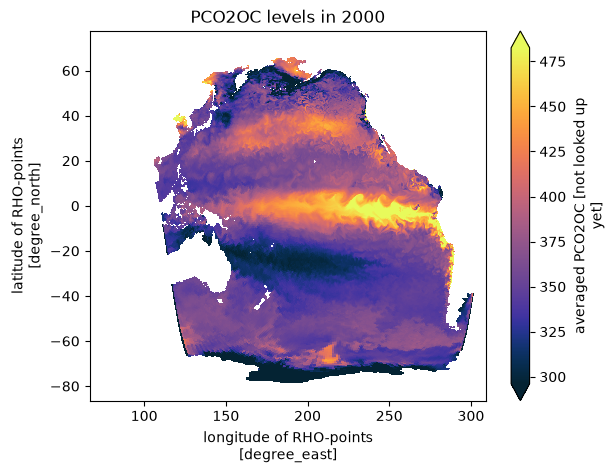

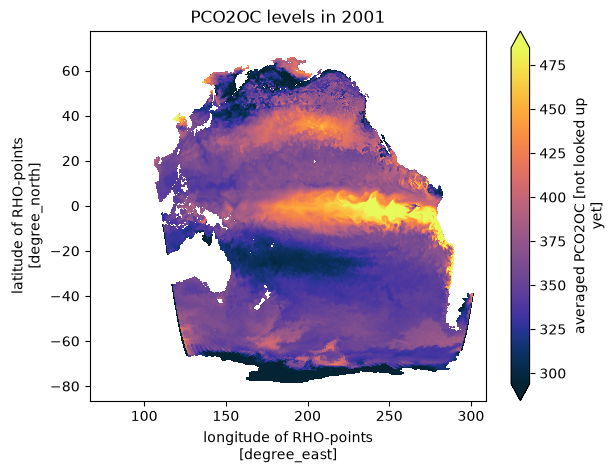

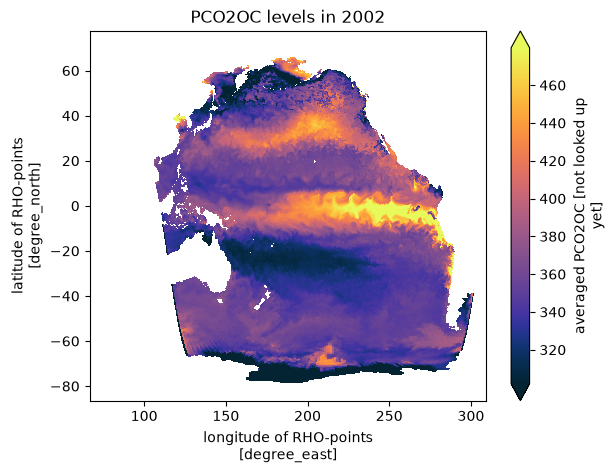

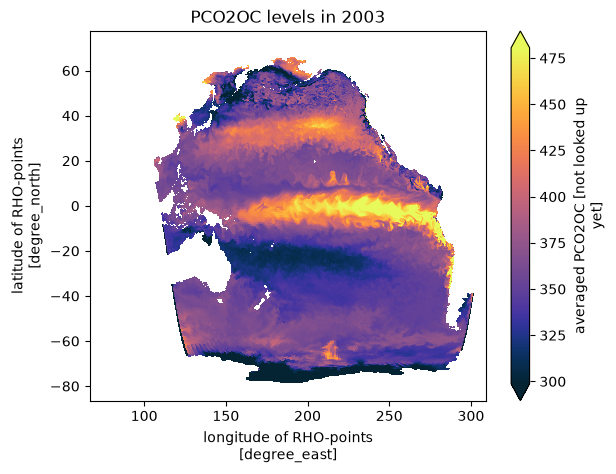

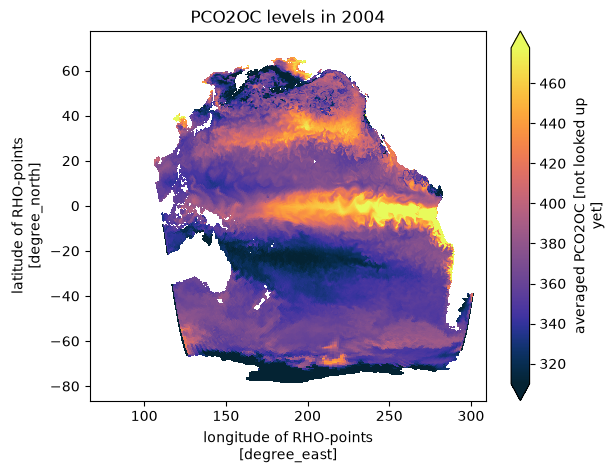

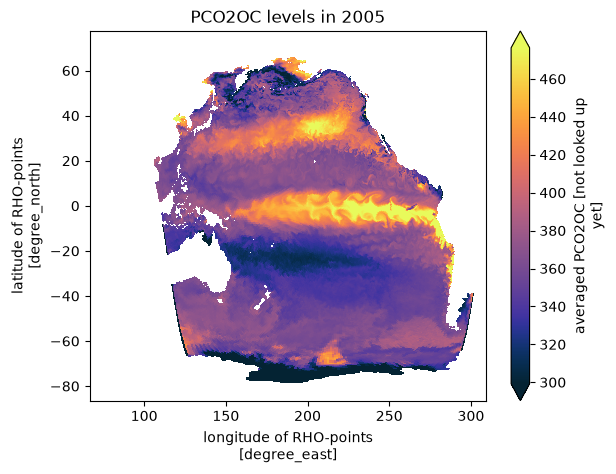

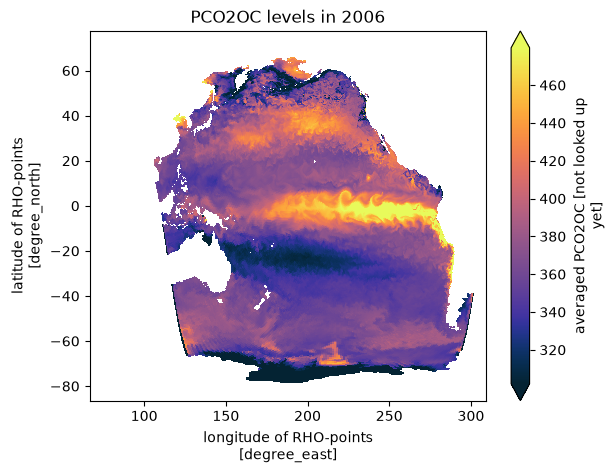

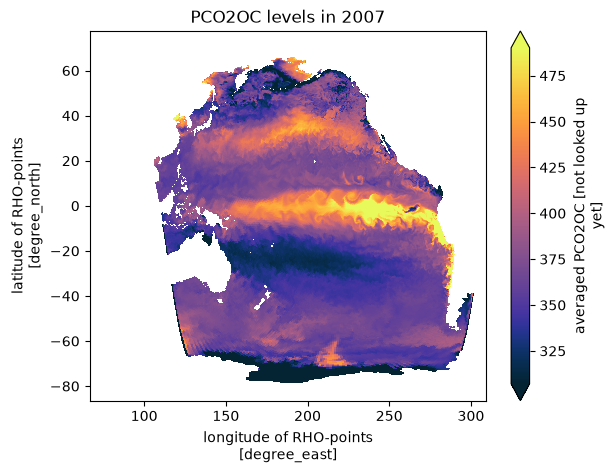

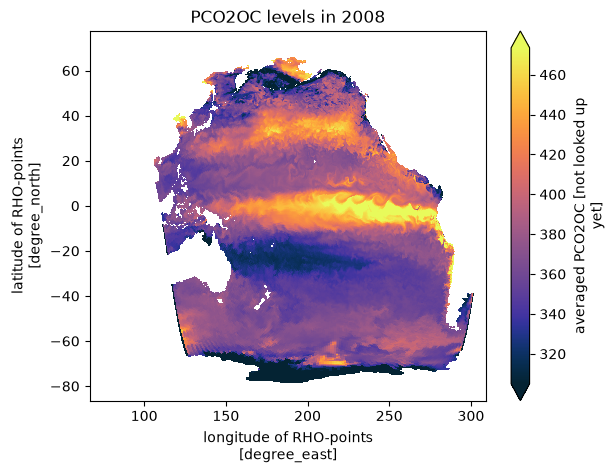

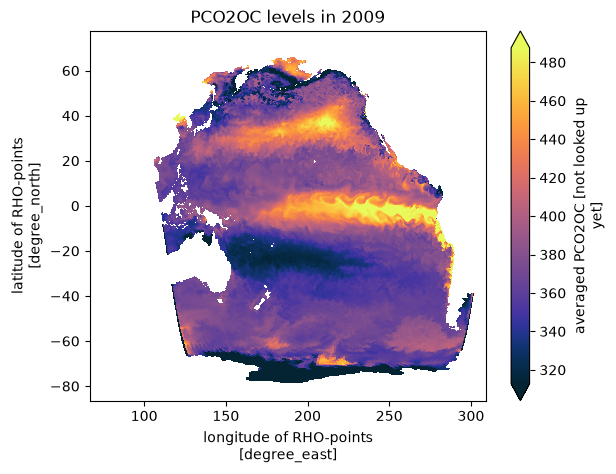

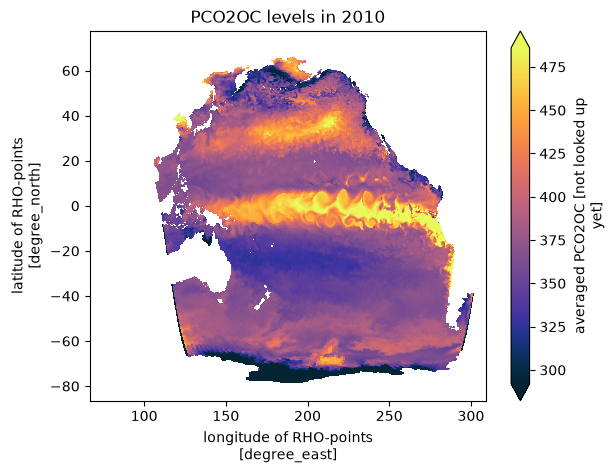

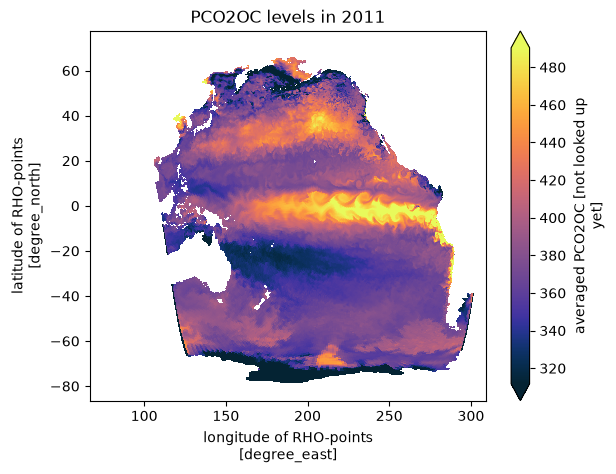

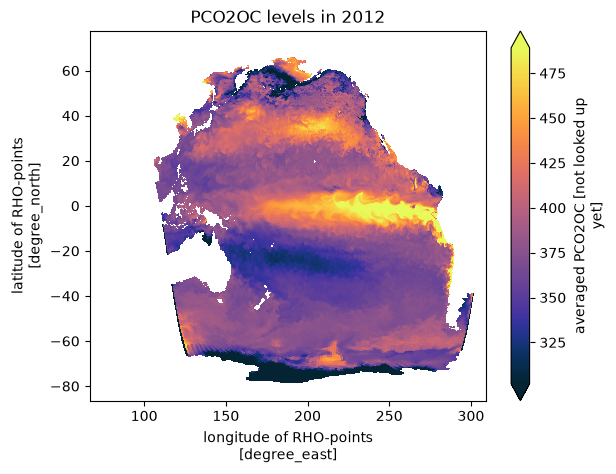

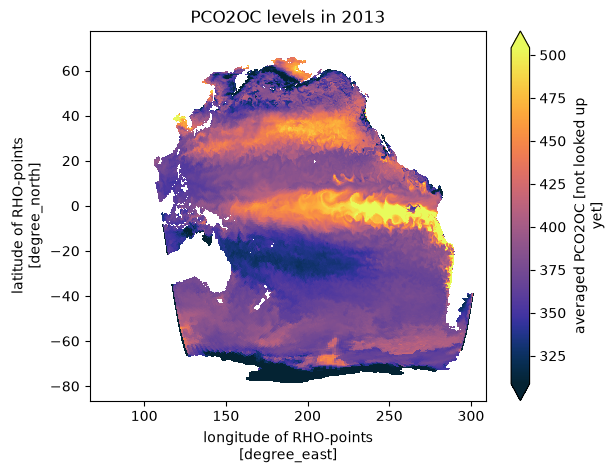

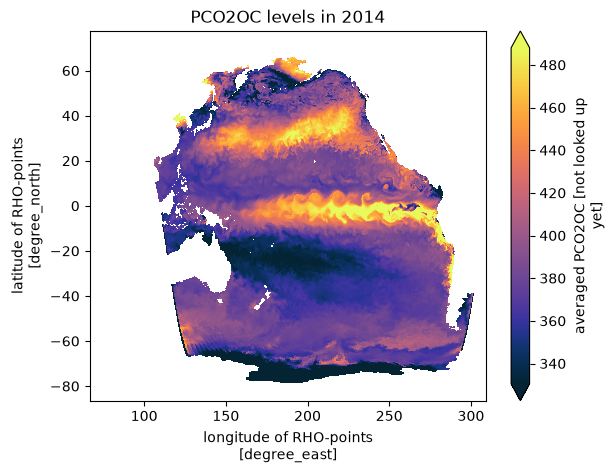

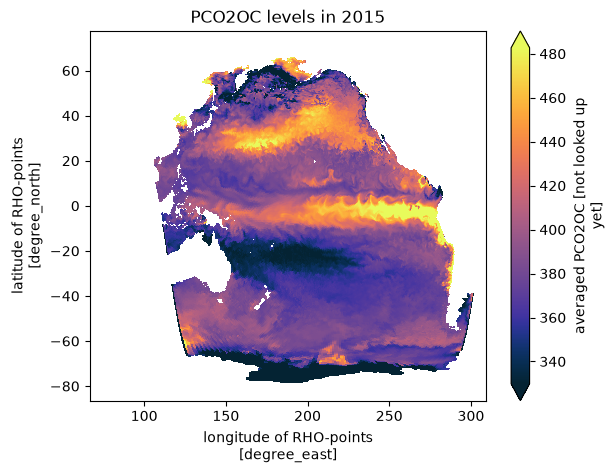

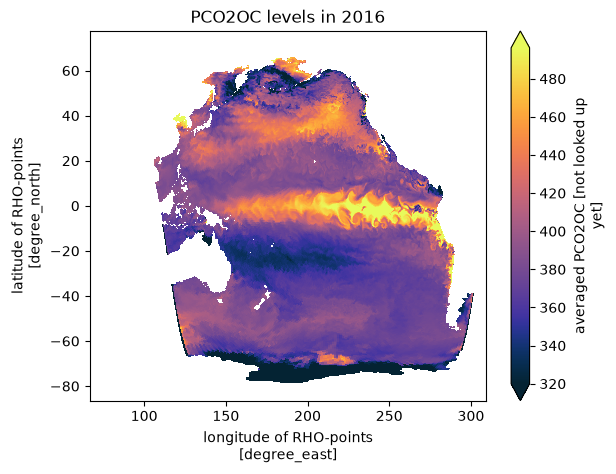

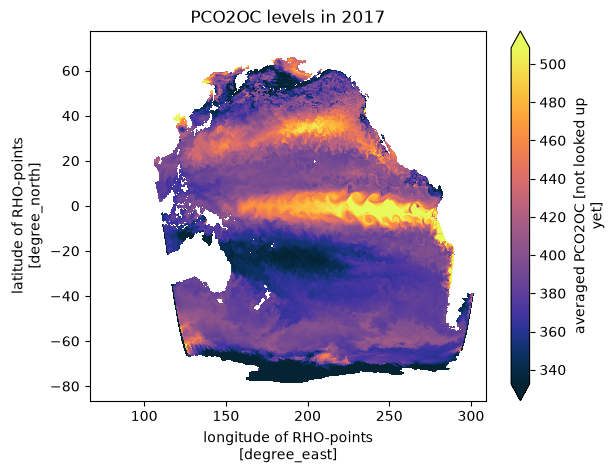

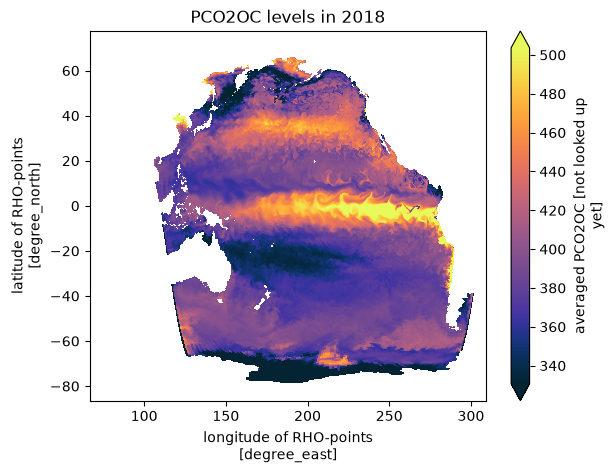

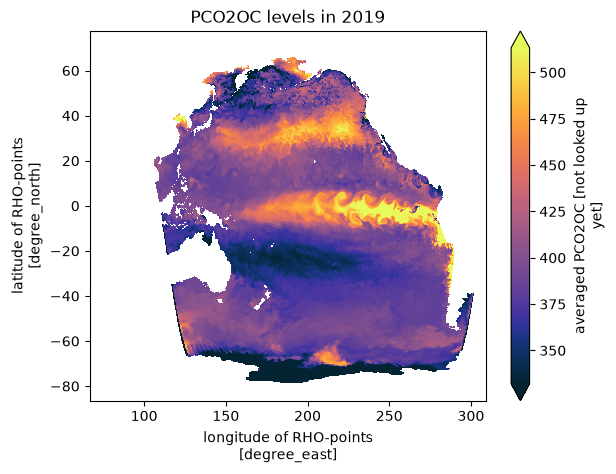

In [23]:
# relev_quant = ["u", "v", "w", "temp", "salt", "zeta", "NO3", "DIC", "PCO2OC", "TOT_CHL"]

def plot_quant_year(quant):

    # Map u and v onto the rho points by interpolating
    if quant in ["u", "v"]:
        for i in range(20):
            vel_data = pactcs30_data[i]
    
            u_rho = 0.5 * (vel_data.u.isel(xi_u=slice(0,-1)) + vel_data.u.isel(xi_u=slice(1, None)))
            u_rho["xi_u"] = u_rho["xi_u"] + 1
            u_rho = u_rho.rename({"xi_u" : "xi_rho"})
            
            v_rho = 0.5 * (vel_data.v.isel(eta_v=slice(0,-1)) + vel_data.v.isel(eta_v=slice(1, None)))
            v_rho["eta_v"] = v_rho["eta_v"] + 1
            v_rho = v_rho.rename({"eta_v" : "eta_rho"})
            
            vel_set = xr.Dataset({
                "u" : u_rho,
                "v" : v_rho,
            })
            
            vel_set = vel_set.assign_coords(lat_rho=vel_data["lat_rho"])
            vel_set = vel_set.assign_coords(lon_rho=vel_data["lon_rho"])
            
            vel_set[quant].isel(time=182).cf.plot(
                x="longitude",
                y="latitude",
                robust=True,
                cmap="cmo.thermal",
            )
            
            plt.title(f"{quant} momentum in {2000+i}")
            plt.show()
        
    else:
        for i in range(20):
            pactcs30_data[i][quant].isel(time=230).cf.plot(
                x="longitude",
                y="latitude",
                robust=True,
                cmap="cmo.thermal",
            )
            
            plt.title(f"{quant} levels in {2000+i}")
            plt.show()

plot_quant_year("NO3")

**What are the long term patterns and trends**

To figure out the patterns, for every variable i plottet them every year around summer and compared between them.

* **Current in u direction:** Currents arround the equator stay roughly the same, currents in the north and south pacific do vary in strenth each year.
* **Current in v direction:** v-momentum is more stable than u-momentum with all currents staying roughly equal over time.
* **Current in w direction:** w-momentum also stays roughly the same over time.
* **Temperature:** Temperature stays roughly the same. There is a cold water area of the coast of northern south america that varies in temperature each year.
* **Salinity:** Salinity stays roughly the same but the high salinity area above the equator that connects both of the high salinity regions varies over time, sometimes vanishing alltogether.
* **Sea level:** Sea levels seem to vary slightly in how far high sea levels spread eastward in the central pacific.
* **Disolved inorganic carbon:** Levels stay roughly the same but how fast DIC levels drop in the north pacific varies slighly each year. The levels on the equator also vary slighly.
* **Partial CO2 pressure:** The partial co2 pressure stays roughly the same on the equator but levels rose in the north pacific.

### **6. Completeness**

This section is a summary of all the anomalies i have found.

* The NO3 and TOT_CHL variables bleed into Australia and south america, meaning there are values on land.
* The NO3 and TOT_CHL variables level out instantaneously every year.
* The median of the v-momentum is always 0.0.
* The minimal value of the PCO2OC variable is always 0.0.

Questions i still have:

* Why does partial CO2 pressure not have a depth component.
* Why is the inverse curvilinear scaling factor for the psi grid stored on the uv grid.